# 📊 Phase 7: Knowledge Discovery & Model Visualizations
In this notebook, we extract the hidden behavioral patterns learned by our Random Forest model. For a Data Mining project, understanding *why* the model makes a decision (Explainable AI) is just as important as the accuracy itself.

We will visualize:
1. **Global Feature Importance:** What variables the AI relies on most.
2. **SHAP Analysis (Game Theory):** How specific behaviors push a user toward being flagged as a thief.
3. **Cost-Sensitive Confusion Matrix:** Proving our model minimizes False Positives.

In [4]:
# Run this once to install required libraries if you don't have them
# !pip install shap seaborn matplotlib pandas scikit-learn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set a clean, professional plotting style for the report
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [5]:
# Load the trained model and the feature list generated by pipeline.py
rf_model = joblib.load("theft_detection_model.pkl")
features = joblib.load("model_features.pkl")

# Load the unseen test data generated in Phase 6
# This guarantees our visualizations represent real-world, unbiased performance
X_test = pd.read_csv("X_test_sample.csv")
y_test = pd.read_csv("y_test_sample.csv").squeeze() # squeeze() turns the 1D dataframe into a Series

print(f"Successfully loaded model and {len(X_test)} unseen test records.")

Successfully loaded model and 1112 unseen test records.


c:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### 1. Global Feature Importance (Random Forest Gini Importance)
This chart answers: *"Which behavioral metrics were most heavily used to build the decision trees?"*

C:\Users\user\AppData\Local\Temp\ipykernel_31588\1546685245.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')


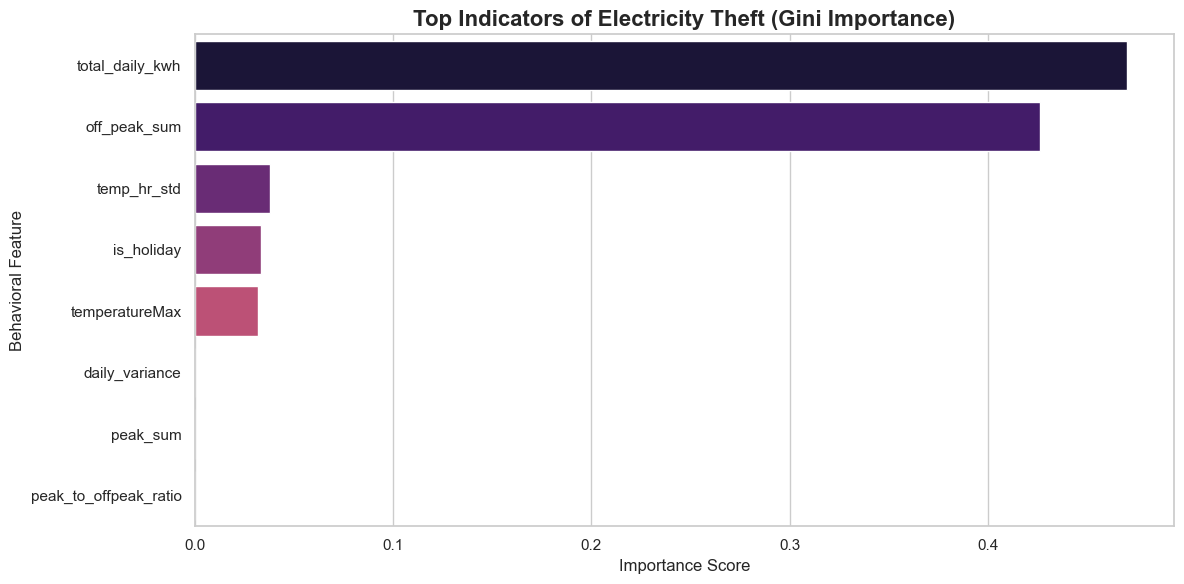

In [ ]:
# Extract importances from the Random Forest
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})

# Sort to get the Top Features
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Create a beautiful Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')

plt.title('Top Indicators of Electricity Theft (Gini Importance)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Behavioral Feature', fontsize=12)
plt.tight_layout()

# Save for the professor's report!
plt.show()

### 2. Explainable AI: SHAP Summary Analysis
While Gini importance shows *what* the model looked at, **SHAP (SHapley Additive exPlanations)** shows *how* it affected the decision. 
* **Red dots** mean the feature value was HIGH.
* **Blue dots** mean the feature value was LOW.
* Dots pushed to the **right** increased the probability of being labeled a thief.

Calculating SHAP values... (This uses game theory and may take a few seconds)


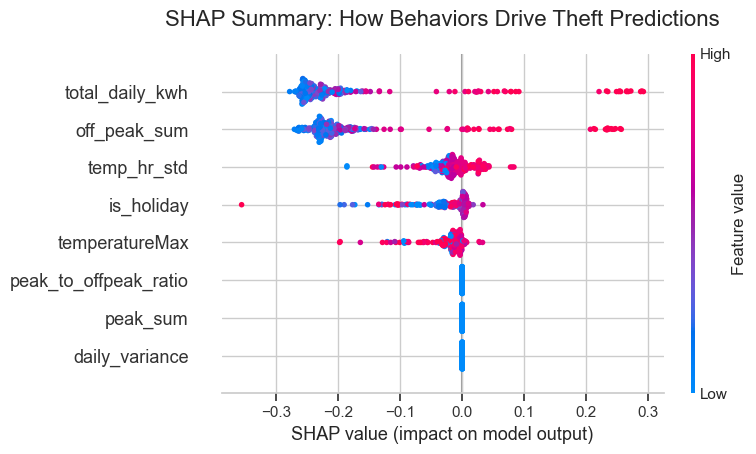

In [ ]:
print("Calculating SHAP values... (This uses game theory and may take a few seconds)")

# Take a sample to speed up SHAP calculation (adjust number if needed)
X_shap_sample = shap.utils.sample(X_test, 300) 

# Create the SHAP Explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap_sample)

# Generate the plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary: How Behaviors Drive Theft Predictions", fontsize=16, pad=20)

# Random Forest returns a list for shap_values. Index 1 represents the 'Thief' class.
shap.summary_plot(shap_values[:, :, 1], X_shap_sample, show=False)

plt.tight_layout()
plt.show()

### 3. Model Evaluation: The Confusion Matrix
In anomaly detection, overall accuracy is misleading. We visualize the Confusion Matrix to prove our model is optimizing for High Precision (minimizing false accusations against innocent customers) while maintaining strong Recall.

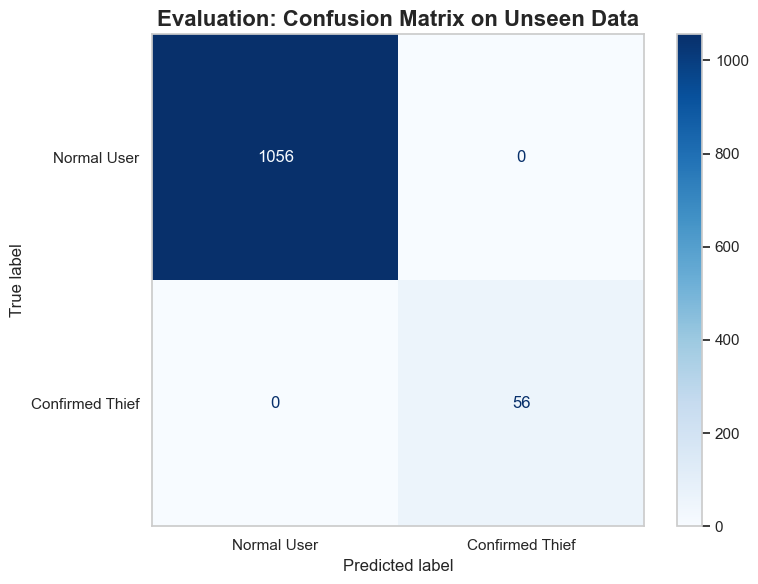

In [ ]:
# Predict on the unseen test data
y_pred = rf_model.predict(X_test)

# Calculate the matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it using a professional blue color map
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal User", "Confirmed Thief"])
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Evaluation: Confusion Matrix on Unseen Data', fontsize=16, fontweight='bold')
plt.grid(False) # Turn off grid lines for a cleaner heatmap
plt.tight_layout()

plt.show()